# EDA PRACTICE

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#Load dataset and inspect structure.
df = pd.read_csv('neenpractice1eda.csv')
df.head() 

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode
0,1001,05-01-2023,Anushree K,East,Furniture,Chairs,1200,2,200,Credit Card
1,1002,07-01-2023,Rahul S,West,Technology,Phones,3000,1,500,COD
2,1003,05-01-2023,Neha P,North,Furniture,Tables,,3,-100,Debit Card
3,1004,12-01-2023,NaN,South,Office Supplies,Binders,500,5,50,Credit Card
4,1005,2023-13-01,Amit R,East,Technology,Laptops,15000,1,3000,UPI


In [3]:
# 2- Check shape and column data types.
df.shape

(12, 10)

In [4]:
type(df)

pandas.core.frame.DataFrame

In [5]:
# 3- Convert Order_Date to datetime.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order_ID       12 non-null     int64 
 1   Order_Date     12 non-null     object
 2   Customer_Name  11 non-null     object
 3   Region         12 non-null     object
 4   Category       11 non-null     object
 5   Sub_Category   12 non-null     object
 6   Sales          11 non-null     object
 7   Quantity       12 non-null     int64 
 8   Profit         12 non-null     int64 
 9   Payment_Mode   11 non-null     object
dtypes: int64(3), object(7)
memory usage: 1.1+ KB


In [6]:
#convert
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors = 'coerce')
df['Order_Date']

0    2023-05-01
1    2023-07-01
2    2023-05-01
3    2023-12-01
4           NaT
5           NaT
6           NaT
7    2023-01-02
8    2023-10-02
9           NaT
10          NaT
11          NaT
Name: Order_Date, dtype: datetime64[ns]

In [8]:
#extract year column
df['Order_Year'] = df['Order_Date'].dt.year
df['Order_Year']

0     2023.0
1     2023.0
2     2023.0
3     2023.0
4        NaN
5        NaN
6        NaN
7     2023.0
8     2023.0
9        NaN
10       NaN
11       NaN
Name: Order_Year, dtype: float64

In [9]:
#extract month
df['Order_Month'] = df['Order_Date'].dt.month
df['Order_Month']

0      5.0
1      7.0
2      5.0
3     12.0
4      NaN
5      NaN
6      NaN
7      1.0
8     10.0
9      NaN
10     NaN
11     NaN
Name: Order_Month, dtype: float64

In [10]:
#check if column exixted or not
df.head()

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month
0,1001,2023-05-01,Anushree K,East,Furniture,Chairs,1200,2,200,Credit Card,2023.0,5.0
1,1002,2023-07-01,Rahul S,West,Technology,Phones,3000,1,500,COD,2023.0,7.0
2,1003,2023-05-01,Neha P,North,Furniture,Tables,,3,-100,Debit Card,2023.0,5.0
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500,5,50,Credit Card,2023.0,12.0
4,1005,NaT,Amit R,East,Technology,Laptops,15000,1,3000,UPI,NaN,NaN


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       12 non-null     int64         
 1   Order_Date     6 non-null      datetime64[ns]
 2   Customer_Name  11 non-null     object        
 3   Region         12 non-null     object        
 4   Category       11 non-null     object        
 5   Sub_Category   12 non-null     object        
 6   Sales          11 non-null     object        
 7   Quantity       12 non-null     int64         
 8   Profit         12 non-null     int64         
 9   Payment_Mode   11 non-null     object        
 10  Order_Year     6 non-null      float64       
 11  Order_Month    6 non-null      float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 1.3+ KB


In [12]:
# 4- Handle invalid date rows. 
#date rows are handled using pd.to_datetime, errors = 'coerce'
df.tail(10)

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month
2,1003,2023-05-01,Neha P,North,Furniture,Tables,,3,-100,Debit Card,2023.0,5.0
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500,5,50,Credit Card,2023.0,12.0
4,1005,NaT,Amit R,East,Technology,Laptops,15000,1,3000,UPI,NaN,NaN
5,1006,NaT,Anushree K,East,Furniture,Chairs,1200,2,200,Credit Card,NaN,NaN
6,1007,NaT,Rahul S,West,Technology,Phones,-3000,1,-500,COD,NaN,NaN
7,1008,2023-01-02,Neha P,North,NaN,Storage,700,4,100,Debit Card,2023.0,1.0
8,1009,2023-10-02,Amit R,East,Technology,Laptops,15000,1,3000,NaN,2023.0,10.0
9,1010,NaT,John D,West,Furniture,Chairs,800,2,150,Credit Card,NaN,NaN
10,1011,NaT,Sara K,South,Office Supplies,Binders,NaN,3,80,COD,NaN,NaN
11,1012,NaT,Anushree K,East,Furniture,Chairs,1200,2,200,Credit Card,NaN,NaN


In [13]:
# 5- Check missing values.
df.isnull().sum()

Order_ID         0
Order_Date       6
Customer_Name    1
Region           0
Category         1
Sub_Category     0
Sales            1
Quantity         0
Profit           0
Payment_Mode     1
Order_Year       6
Order_Month      6
dtype: int64

In [14]:
# 6- Handle missing Sales.
df.describe()

,Order_ID,Order_Date,Quantity,Profit,Order_Year,Order_Month
count,12.000000,6,12.000000,12.000000,6.0,6.000000
mean,1006.500000,2023-06-21 16:00:00,2.250000,573.333333,2023.0,6.666667
min,1001.000000,2023-01-02 00:00:00,1.000000,-500.000000,2023.0,1.000000
25%,1003.750000,2023-05-01 00:00:00,1.000000,72.500000,2023.0,5.000000
50%,1006.500000,2023-05-31 12:00:00,2.000000,175.000000,2023.0,6.000000
75%,1009.250000,2023-09-08 18:00:00,3.000000,275.000000,2023.0,9.250000
max,1012.000000,2023-12-01 00:00:00,5.000000,3000.000000,2023.0,12.000000
std,3.605551,NaN,1.288057,1157.067872,0.0,3.932768


In [18]:
# since not extreme outliers are present (mean almost equals median (50%)) - distribution is symmetric
#hence we fill missing value with mean
df['Sales'].describe()

count       11
unique       8
top       1200
freq         3
Name: Sales, dtype: object

In [20]:
#convert sales column from object data type to int data type
df['Sales'] = pd.to_numeric(df['Sales'], errors = 'coerce')
df['Sales']

0      1200.0
1      3000.0
2         NaN
3       500.0
4     15000.0
5      1200.0
6     -3000.0
7       700.0
8     15000.0
9       800.0
10        NaN
11     1200.0
Name: Sales, dtype: float64

In [21]:
#then handle missing value:
df['Sales'].isnull().sum()

2

In [22]:
#now fill missing value with mean/median --- lets decide
df['Sales'].dtype

dtype('float64')

In [23]:
df['Sales'].describe()

count       10.000000
mean      3560.000000
std       6208.989898
min      -3000.000000
25%        725.000000
50%       1200.000000
75%       2550.000000
max      15000.000000
Name: Sales, dtype: float64

In [24]:
#since mean >> median (50%) means outliers exists, so we fill with median value
df['Sales'] = df['Sales'].fillna(df['Sales'].median())
df['Sales']

0      1200.0
1      3000.0
2      1200.0
3       500.0
4     15000.0
5      1200.0
6     -3000.0
7       700.0
8     15000.0
9       800.0
10     1200.0
11     1200.0
Name: Sales, dtype: float64

In [26]:
df['Sales'].isnull().sum()

0

### 7 - Handle missing Category.

In [29]:
#since category is categorical column, we figure it through, mode 
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])
df['Category'] 

0           Furniture
1          Technology
2           Furniture
3     Office Supplies
4          Technology
5           Furniture
6          Technology
7           Furniture
8          Technology
9           Furniture
10    Office Supplies
11          Furniture
Name: Category, dtype: object

In [30]:
df['Category'].isnull().sum()

0

### 8- Handle missing Payment_Mode.

In [34]:
df['Payment_Mode'].dtype

dtype('O')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       12 non-null     int64         
 1   Order_Date     6 non-null      datetime64[ns]
 2   Customer_Name  11 non-null     object        
 3   Region         12 non-null     object        
 4   Category       12 non-null     object        
 5   Sub_Category   12 non-null     object        
 6   Sales          12 non-null     float64       
 7   Quantity       12 non-null     int64         
 8   Profit         12 non-null     int64         
 9   Payment_Mode   11 non-null     object        
 10  Order_Year     6 non-null      float64       
 11  Order_Month    6 non-null      float64       
dtypes: datetime64[ns](1), float64(3), int64(3), object(5)
memory usage: 1.3+ KB


In [36]:
#fill missing value with mode:
df['Payment_Mode'] = df['Payment_Mode'].fillna(df['Payment_Mode'].mode()[0])
df['Payment_Mode']

0     Credit Card
1             COD
2      Debit Card
3     Credit Card
4             UPI
5     Credit Card
6             COD
7      Debit Card
8     Credit Card
9     Credit Card
10            COD
11    Credit Card
Name: Payment_Mode, dtype: object

### 9- Detect duplicate rows.

In [37]:
df.duplicated().sum()

0

### 10- Remove duplicates.

In [38]:
df.drop_duplicates()

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month
0,1001,2023-05-01,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,2023.0,5.0
1,1002,2023-07-01,Rahul S,West,Technology,Phones,3000.0,1,500,COD,2023.0,7.0
2,1003,2023-05-01,Neha P,North,Furniture,Tables,1200.0,3,-100,Debit Card,2023.0,5.0
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500.0,5,50,Credit Card,2023.0,12.0
4,1005,NaT,Amit R,East,Technology,Laptops,15000.0,1,3000,UPI,NaN,NaN
5,1006,NaT,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,NaN,NaN
6,1007,NaT,Rahul S,West,Technology,Phones,-3000.0,1,-500,COD,NaN,NaN
7,1008,2023-01-02,Neha P,North,Furniture,Storage,700.0,4,100,Debit Card,2023.0,1.0
8,1009,2023-10-02,Amit R,East,Technology,Laptops,15000.0,1,3000,Credit Card,2023.0,10.0
9,1010,NaT,John D,West,Furniture,Chairs,800.0,2,150,Credit Card,NaN,NaN


In [39]:
#view duplicate records
df[df.duplicated()]

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month


# 🔹 DATA VALIDATION

In [40]:
### 11 - Identify negative sales values.
df[df['Sales'] < 0]

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month
6,1007,NaT,Rahul S,West,Technology,Phones,-3000.0,1,-500,COD,NaN,NaN


### 12- Identify negative profit rows.

In [41]:
df[df['Profit'] < 0]

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month
2,1003,2023-05-01,Neha P,North,Furniture,Tables,1200.0,3,-100,Debit Card,2023.0,5.0
6,1007,NaT,Rahul S,West,Technology,Phones,-3000.0,1,-500,COD,NaN,NaN


### 13 - Check if Sales = Quantity * Unit price (if derivable).

In [42]:
df['Unit_Price'] = df['Sales'] / df['Quantity']
df['Unit_Price']

0       600.0
1      3000.0
2       400.0
3       100.0
4     15000.0
5       600.0
6     -3000.0
7       175.0
8     15000.0
9       400.0
10      400.0
11      600.0
Name: Unit_Price, dtype: float64

In [43]:
df.head()

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price
0,1001,2023-05-01,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,2023.0,5.0,600.0
1,1002,2023-07-01,Rahul S,West,Technology,Phones,3000.0,1,500,COD,2023.0,7.0,3000.0
2,1003,2023-05-01,Neha P,North,Furniture,Tables,1200.0,3,-100,Debit Card,2023.0,5.0,400.0
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500.0,5,50,Credit Card,2023.0,12.0,100.0
4,1005,NaT,Amit R,East,Technology,Laptops,15000.0,1,3000,UPI,NaN,NaN,15000.0


In [44]:
#first re-calculate expected sales:
df['Recalculate_Sales'] = df['Sales'] * df['Unit_Price']
df['Recalculate_Sales']

0        720000.0
1       9000000.0
2        480000.0
3         50000.0
4     225000000.0
5        720000.0
6       9000000.0
7        122500.0
8     225000000.0
9        320000.0
10       480000.0
11       720000.0
Name: Recalculate_Sales, dtype: float64

In [46]:
#then verify df['Recalculated_Sales'] == df['Sales']
#Because of floating-point precision, don’t use == directly.
#use round
df['Match'] = round(df['Recalculate_Sales'], 2) == round(df['Sales'], 2)
df['Match']

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
Name: Match, dtype: bool

In [47]:
df[df['Match'] == False] #False means both columns match

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price,Recalculate_Sales,Match
0,1001,2023-05-01,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,2023.0,5.0,600.0,720000.0,False
1,1002,2023-07-01,Rahul S,West,Technology,Phones,3000.0,1,500,COD,2023.0,7.0,3000.0,9000000.0,False
2,1003,2023-05-01,Neha P,North,Furniture,Tables,1200.0,3,-100,Debit Card,2023.0,5.0,400.0,480000.0,False
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500.0,5,50,Credit Card,2023.0,12.0,100.0,50000.0,False
4,1005,NaT,Amit R,East,Technology,Laptops,15000.0,1,3000,UPI,NaN,NaN,15000.0,225000000.0,False
5,1006,NaT,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,NaN,NaN,600.0,720000.0,False
6,1007,NaT,Rahul S,West,Technology,Phones,-3000.0,1,-500,COD,NaN,NaN,-3000.0,9000000.0,False
7,1008,2023-01-02,Neha P,North,Furniture,Storage,700.0,4,100,Debit Card,2023.0,1.0,175.0,122500.0,False
8,1009,2023-10-02,Amit R,East,Technology,Laptops,15000.0,1,3000,Credit Card,2023.0,10.0,15000.0,225000000.0,False
9,1010,NaT,John D,West,Furniture,Chairs,800.0,2,150,Credit Card,NaN,NaN,400.0,320000.0,False


### 13- Check inconsistent date formats.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order_ID           12 non-null     int64         
 1   Order_Date         6 non-null      datetime64[ns]
 2   Customer_Name      11 non-null     object        
 3   Region             12 non-null     object        
 4   Category           12 non-null     object        
 5   Sub_Category       12 non-null     object        
 6   Sales              12 non-null     float64       
 7   Quantity           12 non-null     int64         
 8   Profit             12 non-null     int64         
 9   Payment_Mode       12 non-null     object        
 10  Order_Year         6 non-null      float64       
 11  Order_Month        6 non-null      float64       
 12  Unit_Price         12 non-null     float64       
 13  Recalculate_Sales  12 non-null     float64       
 14  Match       

In [50]:
#check
df['Order_Date'].head(10)

0   2023-05-01
1   2023-07-01
2   2023-05-01
3   2023-12-01
4          NaT
5          NaT
6          NaT
7   2023-01-02
8   2023-10-02
9          NaT
Name: Order_Date, dtype: datetime64[ns]

### 14- Validate Quantity column.

In [58]:
#check missing values
df['Quantity'].isnull().sum()

0

In [57]:
#check outlier (mean equal median -- no outlier present)
df['Quantity'].describe()

count    12.000000
mean      2.250000
std       1.288057
min       1.000000
25%       1.000000
50%       2.000000
75%       3.000000
max       5.000000
Name: Quantity, dtype: float64

In [53]:
df['Quantity'].dtype

dtype('int64')

In [54]:
#negative values:
df[df['Quantity'] < 0]

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price,Recalculate_Sales,Match


In [55]:
#zero values
df[df['Quantity'] == 0]

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price,Recalculate_Sales,Match


<Axes: xlabel='Quantity'>

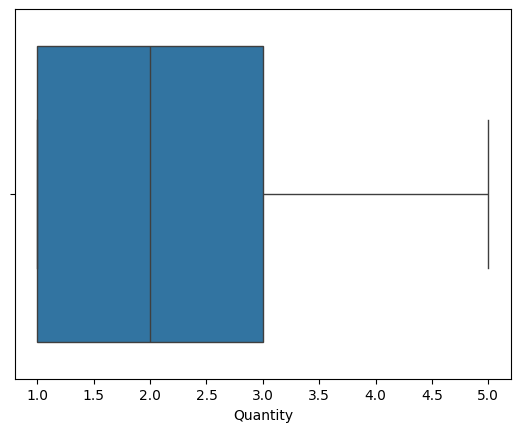

In [59]:
#detect outliers
sns.boxplot(x= df['Quantity'])

In [60]:
#logical cross- validation
# sales = quantity * unit price
#check
df[df['Quantity'] * df['Unit_Price'] != df['Sales']]

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price,Recalculate_Sales,Match


# 🔹 AGGREGATION QUESTIONS

### 15- Total sales by region.

In [61]:
df.head()

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price,Recalculate_Sales,Match
0,1001,2023-05-01,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,2023.0,5.0,600.0,720000.0,False
1,1002,2023-07-01,Rahul S,West,Technology,Phones,3000.0,1,500,COD,2023.0,7.0,3000.0,9000000.0,False
2,1003,2023-05-01,Neha P,North,Furniture,Tables,1200.0,3,-100,Debit Card,2023.0,5.0,400.0,480000.0,False
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500.0,5,50,Credit Card,2023.0,12.0,100.0,50000.0,False
4,1005,NaT,Amit R,East,Technology,Laptops,15000.0,1,3000,UPI,NaN,NaN,15000.0,225000000.0,False


In [62]:
total_sales_by_region = df.groupby('Region')['Sales'].sum()
total_sales_by_region

Region
East     33600.0
North     1900.0
South     1700.0
West       800.0
Name: Sales, dtype: float64

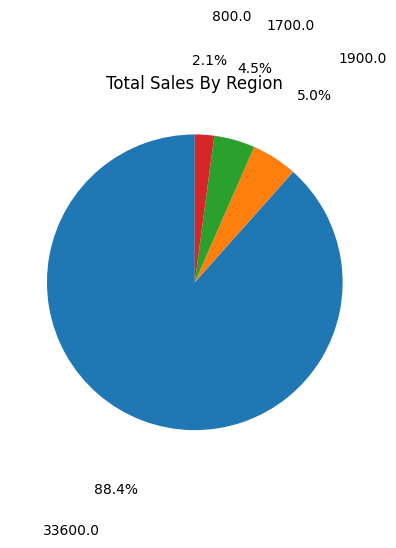

In [80]:
#plot graph
plt.pie(total_sales_by_region, 
        labels = total_sales_by_region,  
        autopct='%1.1f%%', 
        startangle = 90,  pctdistance= 1.5,     # moves percentage outside
    labeldistance= 1.8 )  # moves labels outside

plt.title('Total Sales By Region')
plt.show()

In [69]:
### 16- Total profit by category.
total_profit_by_category = df.groupby('Category')['Profit'].sum()
total_profit_by_category

Category
Furniture           750
Office Supplies     130
Technology         6000
Name: Profit, dtype: int64

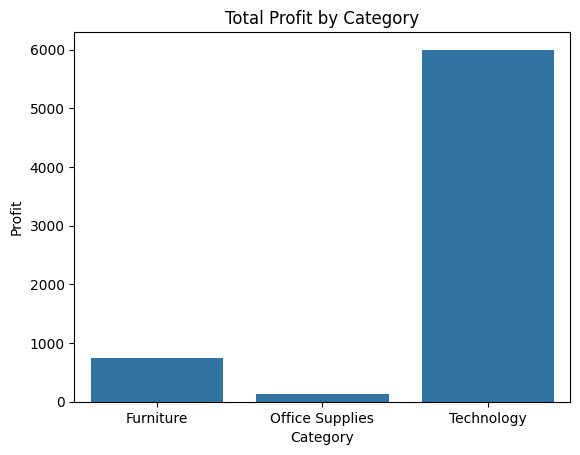

In [84]:
#bar char
sns.barplot(x = 'Category', y = 'Profit', data =total_profit_by_category )

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')

plt.show()

In [83]:
#convert series into a Data Frame
total_profit_by_category = total_profit_by_category.reset_index()
total_profit_by_category

,index,Category,Profit
0,0,Furniture,750
1,1,Office Supplies,130
2,2,Technology,6000


<Axes: xlabel='Customer_Name'>

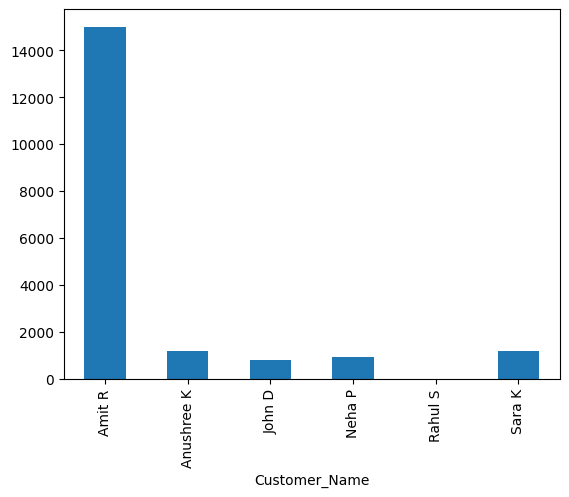

In [87]:
### 17- Average sales per customer.
avg_sales_per_customer = df.groupby('Customer_Name')['Sales'].mean().plot(kind = 'bar')
avg_sales_per_customer

### 18- Highest revenue by region

In [91]:
highest_region = total_sales_by_region.idxmax()
highest_revenue = total_sales_by_region.max()

print(highest_region, "Highest Region")
print(highest_revenue, "Highest Revenue")

East Highest Region
33600.0 Highest Revenue


### 19- Top 3 customers by revenue.


In [95]:
top_3_customer = df.groupby('Customer_Name')['Sales'].sum().sort_values(ascending = False).head(3).reset_index()
top_3_customer

,Customer_Name,Sales
0,Amit R,30000.0
1,Anushree K,3600.0
2,Neha P,1900.0


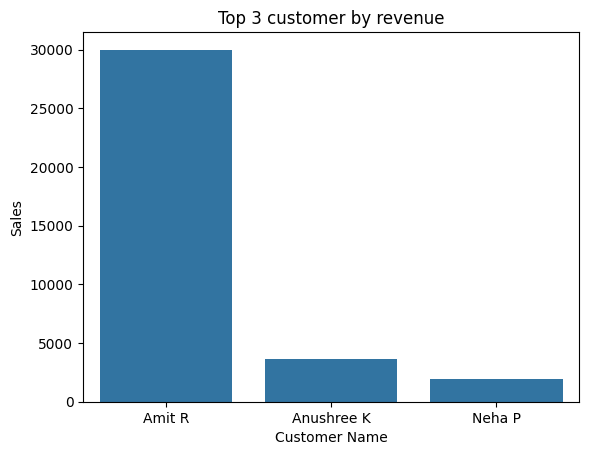

In [97]:
sns.barplot(x = 'Customer_Name', y = 'Sales', data = top_3_customer)

plt.title('Top 3 customer by revenue')
plt.xlabel('Customer Name')
plt.ylabel('Sales')
plt.show()

# 🔹 BUSINESS THINKING

### 20- Which category has highest profit margin?

In [102]:
category_margin = df.groupby('Category').agg({
    'Profit': 'sum',
    'Sales' : 'sum'
})

category_margin['Profit_Margin'] = category_margin['Profit']/category_margin['Sales']
category_margin['Profit_Margin']

Category
Furniture          0.119048
Office Supplies    0.076471
Technology         0.200000
Name: Profit_Margin, dtype: float64

### 21- Month-wise sales trend.

In [114]:
month_sales_trend = df.groupby('Order_Month')['Sales'].sum().reset_index()
month_sales_trend

,Order_Month,Sales
0,December,500.0
1,January,700.0
2,July,3000.0
3,May,2400.0
4,October,15000.0


In [107]:
#convert to integer
# And integers cannot store NaN values in normal NumPy int type.
#  float supports NaN (Currently is in Float)
df = df.dropna(subset = ['Order_Month'])

In [109]:
#now convert into int
df['Order_Month'] = df['Order_Month'].astype(int)
df['Order_Month']

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5140\1202746184.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Month'] = df['Order_Month'].astype(int)


0     5
1     7
2     5
3    12
7     1
8    10
Name: Order_Month, dtype: int32

In [112]:
#convert Order_Month from Int data type to Object (Like Jan, Feb..)
df['Order_Month'] = df['Order_Date'].dt.month_name()
df['Order_Month']

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5140\18826141.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Order_Month'] = df['Order_Date'].dt.month_name()


0         May
1        July
2         May
3    December
7     January
8     October
Name: Order_Month, dtype: object

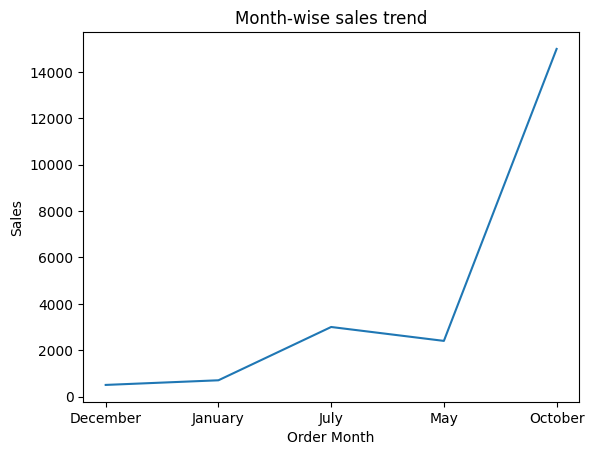

In [115]:
sns.lineplot(x = 'Order_Month', y = 'Sales', data = month_sales_trend)

plt.title('Month-wise sales trend')
plt.xlabel('Order Month')
plt.ylabel('Sales')

plt.show()

### 22- Payment mode contribution percentage.

In [116]:
df.head()

,Order_ID,Order_Date,Customer_Name,Region,Category,Sub_Category,Sales,Quantity,Profit,Payment_Mode,Order_Year,Order_Month,Unit_Price,Recalculate_Sales,Match
0,1001,2023-05-01,Anushree K,East,Furniture,Chairs,1200.0,2,200,Credit Card,2023.0,May,600.0,720000.0,False
1,1002,2023-07-01,Rahul S,West,Technology,Phones,3000.0,1,500,COD,2023.0,July,3000.0,9000000.0,False
2,1003,2023-05-01,Neha P,North,Furniture,Tables,1200.0,3,-100,Debit Card,2023.0,May,400.0,480000.0,False
3,1004,2023-12-01,NaN,South,Office Supplies,Binders,500.0,5,50,Credit Card,2023.0,December,100.0,50000.0,False
7,1008,2023-01-02,Neha P,North,Furniture,Storage,700.0,4,100,Debit Card,2023.0,January,175.0,122500.0,False


In [118]:
#What % of total revenue comes from each payment mode.
payment_mode_percentage = df.groupby('Payment_Mode')['Sales'].sum().reset_index()
payment_mode_percentage

,Payment_Mode,Sales
0,COD,3000.0
1,Credit Card,16700.0
2,Debit Card,1900.0


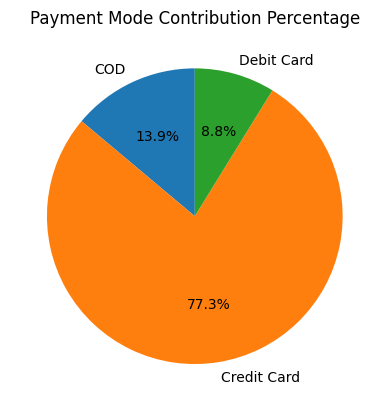

In [120]:
plt.pie(
    payment_mode_percentage['Sales'],
    labels=payment_mode_percentage['Payment_Mode'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Payment Mode Contribution Percentage')
plt.show()


### 23- Region-wise average profit.

In [124]:
region_wise_avg_profit = df.groupby('Region')['Profit'].mean().reset_index()
c

,Region,Profit
0,East,1600.0
1,North,0.0
2,South,50.0
3,West,500.0


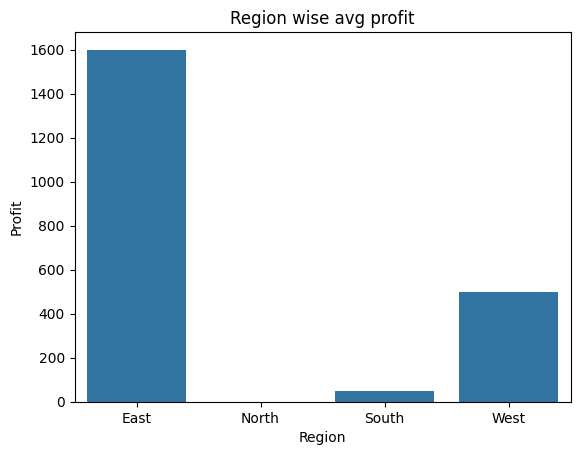

In [125]:
sns.barplot(x = 'Region', y = 'Profit', data = region_wise_avg_profit)

plt.title('Region wise avg profit')
plt.xlabel('Region')
plt.ylabel('Profit')

plt.show()

### 24- Sub-category performance analysis.

In [127]:
sub_category_by_revenue = df.groupby('Sub_Category')['Sales'].sum().reset_index()
sub_category_by_revenue

,Sub_Category,Sales
0,Binders,500.0
1,Chairs,1200.0
2,Laptops,15000.0
3,Phones,3000.0
4,Storage,700.0
5,Tables,1200.0


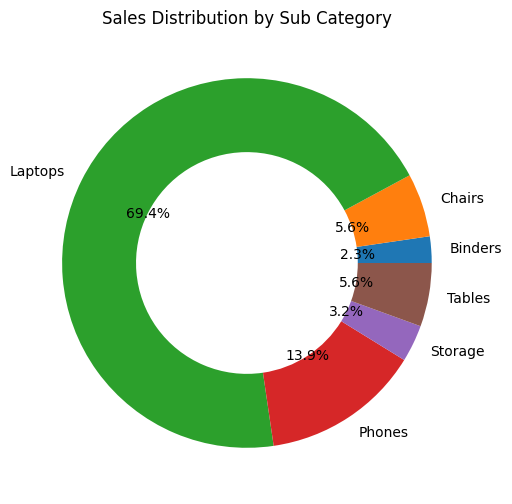

In [129]:
plt.figure(figsize=(6,6))

plt.pie(
    sub_category_by_revenue['Sales'],
    labels=sub_category_by_revenue['Sub_Category'],
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title('Sales Distribution by Sub Category')
plt.show()

# 🔹 ADVANCED EDA

### 25- Detect outliers in Sales.

In [130]:
df['Sales'].describe()

count        6.000000
mean      3600.000000
std       5654.378834
min        500.000000
25%        825.000000
50%       1200.000000
75%       2550.000000
max      15000.000000
Name: Sales, dtype: float64

In [131]:
#detect outliers
from scipy import stats
import numpy as np

z_scores = np.abs(stats.zscore(df['Sales']))
z_scores

0    0.464961
1    0.116240
2    0.464961
3    0.600575
7    0.561828
8    2.208567
Name: Sales, dtype: float64

<Axes: xlabel='Sales'>

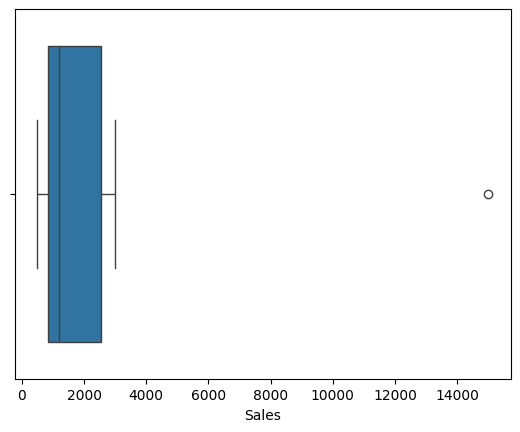

In [132]:
#boxplot
sns.boxplot(x= df['Sales'])

### 26- Calculate month-over-month growth.

In [133]:
#step 1- Make sure dates are sorted:
df = df.sort_values('Order_Date')

In [134]:
#step 2- Year Month period
df['YearMonth'] = df['Order_Date'].dt.to_period('M')

In [136]:
#Now calculate monthly sales:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales

,YearMonth,Sales
0,2023-01,700.0
1,2023-05,2400.0
2,2023-07,3000.0
3,2023-10,15000.0
4,2023-12,500.0


In [137]:
#Step 3 — Calculate Previous Month Sales
monthly_sales['Previous_Month_Sales'] = monthly_sales['Sales'].shift(1)


In [142]:
#Step 4 — Calculate MoM Growth %
monthly_sales['MoM_Growth_%'] = (monthly_sales['Sales'] - monthly_sales['Previous_Month_Sales'] / monthly_sales['Previous_Month_Sales'])*100
monthly_sales['MoM_Growth_%']

0          NaN
1     239900.0
2     299900.0
3    1499900.0
4      49900.0
Name: MoM_Growth_%, dtype: float64

In [143]:
monthly_sales['MoM_Growth_%'].reset_index()

,index,MoM_Growth_%
0,0,NaN
1,1,239900.0
2,2,299900.0
3,3,1499900.0
4,4,49900.0


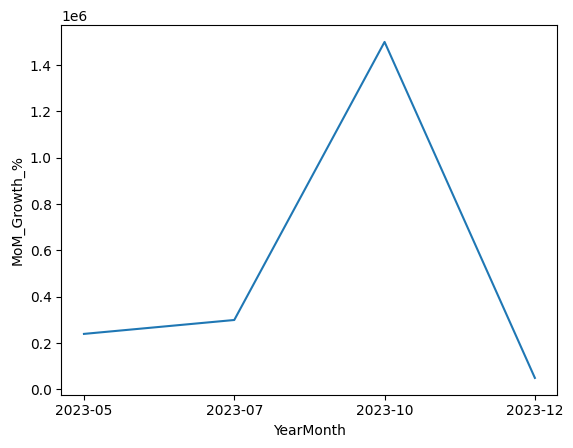

In [149]:
sns.lineplot(x='YearMonth', y='MoM_Growth_%', data=monthly_sales)
#plt.axhline(0, color='red', linestyle='--')
plt.show()

In [148]:
#Fix 1 — Convert Period to String
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
